<a href="https://colab.research.google.com/github/minasaeday14/INFO-5731-spring-2026/blob/main/Saeday_Mina_5731_Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


Using dataset: /content/exercise05_datacollection-1.zip
Files inside zip:
['exercise09_datacollection/', 'exercise09_datacollection/stsa-test.txt', 'exercise09_datacollection/stsa-train.txt']

Dataset choice:
I selected Option 2 and used a Stanford Sentiment Treebank-style movie review sentiment dataset. The dataset contains real-world movie review sentences labeled as positive or negative. Although the assignment prefers positive, negative, and neutral labels, it allows a well-justified binary sentiment dataset.

Training data shape: (6920, 3)
Testing data shape: (1821, 3)


,label,text,sentiment
0,1,"a stirring , funny and finally transporting re...",positive
1,0,apparently reassembled from the cutting-room f...,negative
2,0,they presume their audience wo n't sit still f...,negative
3,1,this is a visually stunning rumination on love...,positive
4,1,jonathan parker 's bartleby should have been t...,positive



Class distribution:
sentiment
positive    3610
negative    3310
Name: count, dtype: int64

Class imbalance ratio: 1.09
The dataset is fairly balanced, so resampling is not required.


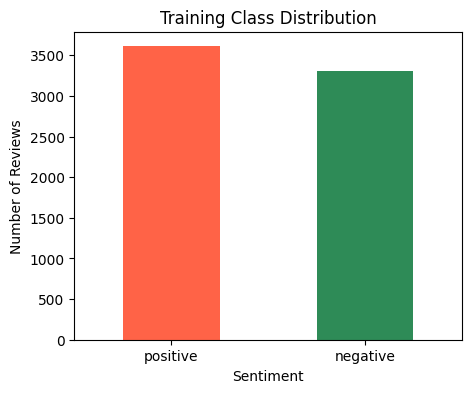

,text,clean_text,sentiment,sentence_length
0,"a stirring , funny and finally transporting re...",stirring funny finally transporting imagining ...,positive,17
1,apparently reassembled from the cutting-room f...,apparently reassembled cutting room floor give...,negative,12
2,they presume their audience wo n't sit still f...,presume audience n't sit sociology lesson ente...,negative,35
3,this is a visually stunning rumination on love...,visually stunning rumination love memory histo...,positive,20
4,jonathan parker 's bartleby should have been t...,jonathan parker bartleby end modern office ano...,positive,15


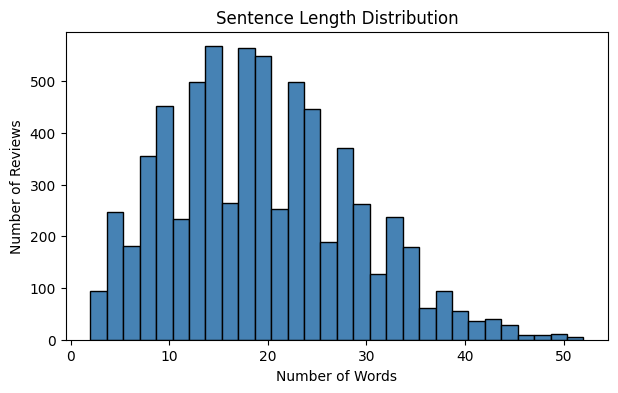


Sentence length summary:


,sentence_length
count,6920.000000
mean,19.299855
std,9.318495
min,2.000000
25%,12.000000
50%,19.000000
75%,25.000000
max,52.000000


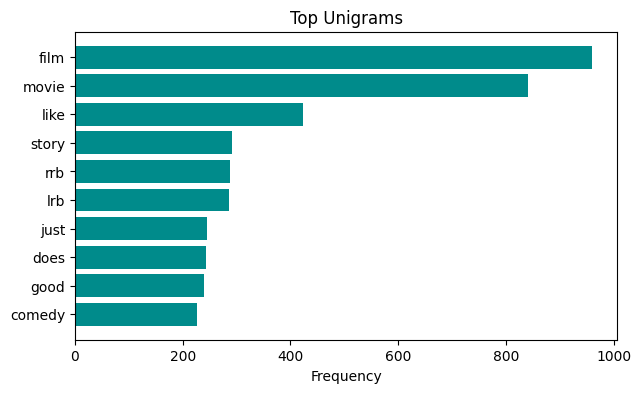

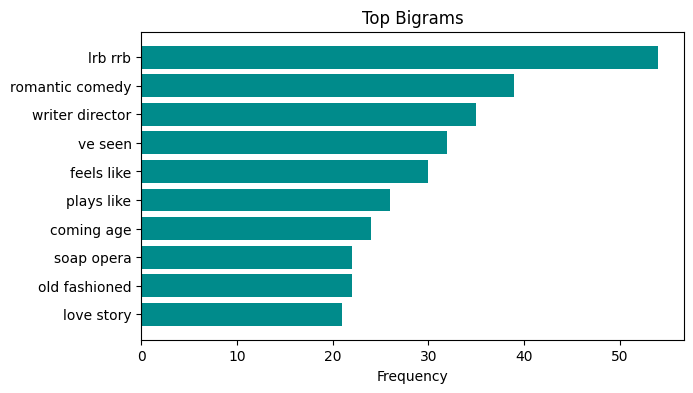


Training Naive Bayes...
              precision    recall  f1-score   support

    negative       0.81      0.70      0.75       912
    positive       0.74      0.84      0.78       909

    accuracy                           0.77      1821
   macro avg       0.77      0.77      0.77      1821
weighted avg       0.77      0.77      0.77      1821


Training Linear SVM...
              precision    recall  f1-score   support

    negative       0.78      0.76      0.77       912
    positive       0.77      0.79      0.78       909

    accuracy                           0.77      1821
   macro avg       0.78      0.77      0.77      1821
weighted avg       0.78      0.77      0.77      1821


Training Logistic Regression...
              precision    recall  f1-score   support

    negative       0.79      0.79      0.79       912
    positive       0.79      0.79      0.79       909

    accuracy                           0.79      1821
   macro avg       0.79      0.79      0.79   

,Model,Accuracy,Precision,Recall,F1-score
2,Logistic Regression,0.788578,0.788597,0.788578,0.788576
1,Linear SVM,0.774849,0.775121,0.774849,0.774801
0,Naive Bayes,0.769357,0.774498,0.769357,0.768309


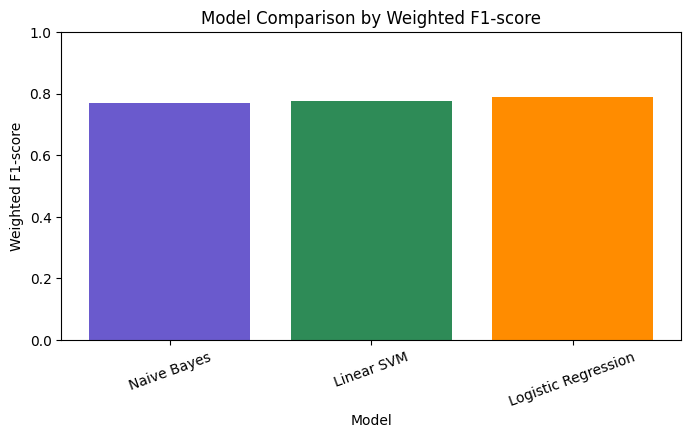


Summary:
The best performing model was Logistic Regression with a weighted F1-score of 0.7886. TF-IDF features worked well because movie review sentiment often depends on positive and negative words. The class distribution was checked, and balanced class weights were used for SVM and Logistic Regression.


In [16]:
# Question 1: Sentiment Analysis

import glob
import re
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression


# -----------------------------
# 1. Find uploaded zip file
# -----------------------------

zip_files = glob.glob("/content/*.zip")

if len(zip_files) == 0:
    raise FileNotFoundError("No zip file found. Upload exercise05_datacollection-1.zip using the left Files panel.")

zip_path = zip_files[0]
print("Using dataset:", zip_path)

with zipfile.ZipFile(zip_path) as z:
    print("Files inside zip:")
    print(z.namelist())

train_member = "exercise09_datacollection/stsa-train.txt"
test_member = "exercise09_datacollection/stsa-test.txt"


def load_stsa_from_zip(zip_path, member_name):
    rows = []

    with zipfile.ZipFile(zip_path) as z:
        with z.open(member_name) as file:
            for raw_line in file:
                line = raw_line.decode("utf-8").strip()

                if line:
                    label, text = line.split(" ", 1)
                    rows.append({
                        "label": int(label),
                        "text": text
                    })

    return pd.DataFrame(rows)


train_df = load_stsa_from_zip(zip_path, train_member)
test_df = load_stsa_from_zip(zip_path, test_member)

label_map = {
    0: "negative",
    1: "positive"
}

train_df["sentiment"] = train_df["label"].map(label_map)
test_df["sentiment"] = test_df["label"].map(label_map)

print("\nDataset choice:")
print(
    "I selected Option 2 and used a Stanford Sentiment Treebank-style movie review sentiment dataset. "
    "The dataset contains real-world movie review sentences labeled as positive or negative. "
    "Although the assignment prefers positive, negative, and neutral labels, it allows a well-justified "
    "binary sentiment dataset."
)

print("\nTraining data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

display(train_df.head())


# -----------------------------
# 2. Class distribution
# -----------------------------

class_counts = train_df["sentiment"].value_counts()
print("\nClass distribution:")
print(class_counts)

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio < 1.5:
    print("The dataset is fairly balanced, so resampling is not required.")
else:
    print("The dataset has class imbalance, so balanced class weights are used where possible.")

plt.figure(figsize=(5, 4))
class_counts.plot(kind="bar", color=["tomato", "seagreen"])
plt.title("Training Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()


# -----------------------------
# 3. Text cleaning and preprocessing
# -----------------------------

stop_words = set(ENGLISH_STOP_WORDS)

def preprocess_text(text):
    text = text.lower()
    tokens = re.findall(r"[a-z']+", text)

    tokens = [
        token for token in tokens
        if token not in stop_words and len(token) > 2
    ]

    return " ".join(tokens)


train_df["clean_text"] = train_df["text"].apply(preprocess_text)
test_df["clean_text"] = test_df["text"].apply(preprocess_text)

train_df["sentence_length"] = train_df["text"].apply(lambda x: len(x.split()))
test_df["sentence_length"] = test_df["text"].apply(lambda x: len(x.split()))

display(train_df[["text", "clean_text", "sentiment", "sentence_length"]].head())


# -----------------------------
# 4. EDA
# -----------------------------

plt.figure(figsize=(7, 4))
plt.hist(train_df["sentence_length"], bins=30, color="steelblue", edgecolor="black")
plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

print("\nSentence length summary:")
display(train_df["sentence_length"].describe())


def plot_top_ngrams(text_series, ngram_range=(1, 1), top_n=10, title="Top Terms"):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        max_features=top_n
    )

    counts = vectorizer.fit_transform(text_series)
    terms = vectorizer.get_feature_names_out()
    frequencies = counts.sum(axis=0).A1

    freq_df = pd.DataFrame({
        "term": terms,
        "frequency": frequencies
    }).sort_values("frequency", ascending=True)

    plt.figure(figsize=(7, 4))
    plt.barh(freq_df["term"], freq_df["frequency"], color="darkcyan")
    plt.title(title)
    plt.xlabel("Frequency")
    plt.show()


plot_top_ngrams(train_df["clean_text"], (1, 1), 10, "Top Unigrams")
plot_top_ngrams(train_df["clean_text"], (2, 2), 10, "Top Bigrams")


# -----------------------------
# 5. Train three traditional ML models
# -----------------------------

models = {
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(class_weight="balanced", max_iter=3000),
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=500)
}

results = []

X_train = train_df["clean_text"]
y_train = train_df["label"]

X_test = test_df["clean_text"]
y_test = test_df["label"]

for model_name, classifier in models.items():
    print(f"\nTraining {model_name}...")

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=2000,
            ngram_range=(1, 1)
        )),
        ("clf", classifier)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-score": f1_score(y_test, y_pred, average="weighted")
    })

    print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))


# -----------------------------
# 6. Results and summary
# -----------------------------

results_df = pd.DataFrame(results)
display(results_df.sort_values("F1-score", ascending=False))

plt.figure(figsize=(8, 4))
plt.bar(results_df["Model"], results_df["F1-score"], color=["slateblue", "seagreen", "darkorange"])
plt.title("Model Comparison by Weighted F1-score")
plt.xlabel("Model")
plt.ylabel("Weighted F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

best_row = results_df.sort_values("F1-score", ascending=False).iloc[0]

print("\nSummary:")
print(
    f"The best performing model was {best_row['Model']} with a weighted F1-score of "
    f"{best_row['F1-score']:.4f}. TF-IDF features worked well because movie review sentiment "
    "often depends on positive and negative words. The class distribution was checked, and "
    "balanced class weights were used for SVM and Logistic Regression."
)


## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


Using zip file: /content/exercise05_datacollection-1.zip
Files inside zip:
['exercise09_datacollection/', 'exercise09_datacollection/stsa-test.txt', 'exercise09_datacollection/stsa-train.txt']

Training file: exercise09_datacollection/stsa-train.txt
Testing file: exercise09_datacollection/stsa-test.txt

Training dataset shape: (6920, 3)
Testing dataset shape: (1821, 3)


,label,text,sentiment
0,1,"a stirring , funny and finally transporting re...",positive
1,0,apparently reassembled from the cutting-room f...,negative
2,0,they presume their audience wo n't sit still f...,negative
3,1,this is a visually stunning rumination on love...,positive
4,1,jonathan parker 's bartleby should have been t...,positive


,label,text,sentiment
0,0,"no movement , no yuks , not much of anything .",negative
1,0,"a gob of drivel so sickly sweet , even the eag...",negative
2,0,"gangs of new york is an unapologetic mess , wh...",negative
3,0,"we never really feel involved with the story ,...",negative
4,1,this is one of polanski 's best films .,positive



Training class distribution:
sentiment
positive    3610
negative    3310
Name: count, dtype: int64

Testing class distribution:
sentiment
negative    912
positive    909
Name: count, dtype: int64


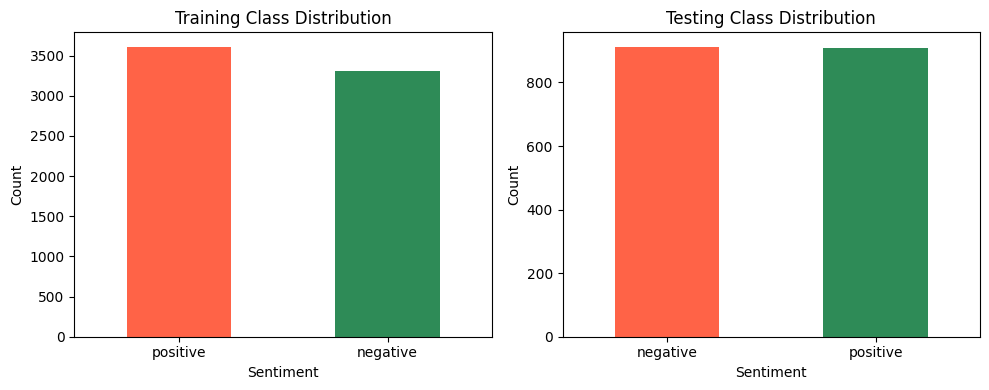

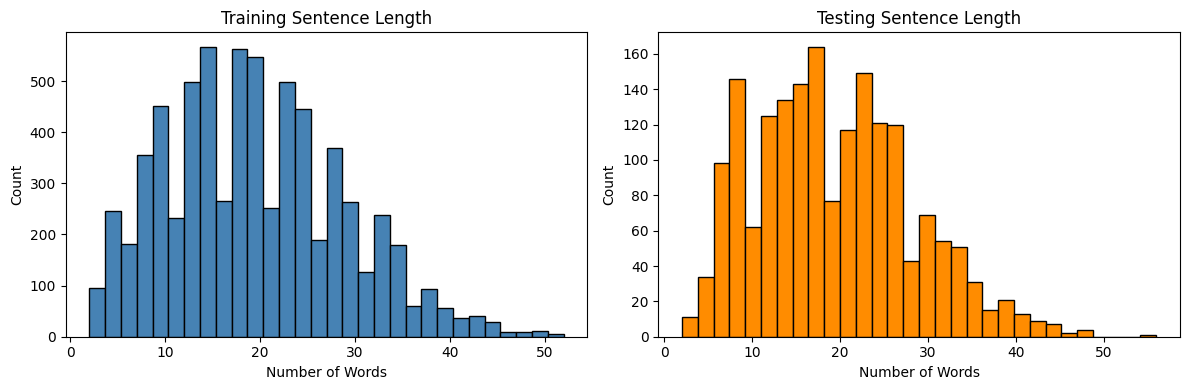


Training sentence length summary:


,sentence_length
count,6920.000000
mean,19.299855
std,9.318495
min,2.000000
25%,12.000000
50%,19.000000
75%,25.000000
max,52.000000



Testing sentence length summary:


,sentence_length
count,1821.000000
mean,19.232839
std,8.922846
min,2.000000
25%,12.000000
50%,18.000000
75%,25.000000
max,56.000000


,text,clean_text,sentiment
0,"a stirring , funny and finally transporting re...",stirring funny finally transporting imagining ...,positive
1,apparently reassembled from the cutting-room f...,apparently reassembled cutting room floor give...,negative
2,they presume their audience wo n't sit still f...,presume audience n't sit sociology lesson ente...,negative
3,this is a visually stunning rumination on love...,visually stunning rumination love memory histo...,positive
4,jonathan parker 's bartleby should have been t...,jonathan parker bartleby end modern office ano...,positive


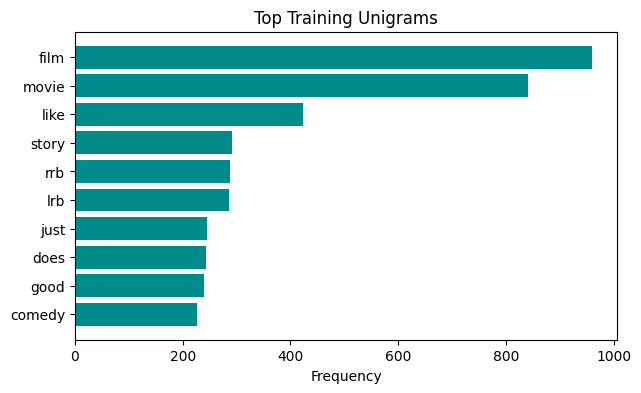

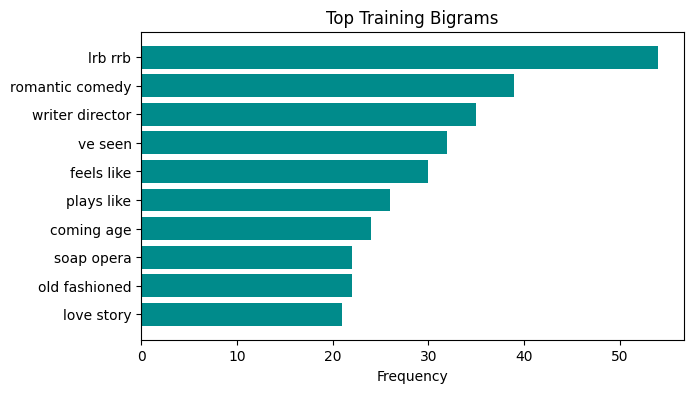

Training split size: 5536
Validation split size: 1384
Test size: 1821

Training model: SVM
10-fold CV weighted F1 scores: [0.76181678 0.75625322 0.73106712 0.75069406 0.75614486 0.73785512
 0.71074867 0.75779948 0.7233653  0.72694394]
Mean CV weighted F1: 0.7413

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.73      0.73       662
    positive       0.75      0.75      0.75       722

    accuracy                           0.74      1384
   macro avg       0.74      0.74      0.74      1384
weighted avg       0.74      0.74      0.74      1384


Final Test Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.76      0.78       912
    positive       0.77      0.80      0.78       909

    accuracy                           0.78      1821
   macro avg       0.78      0.78      0.78      1821
weighted avg       0.78      0.78      0.78      1821



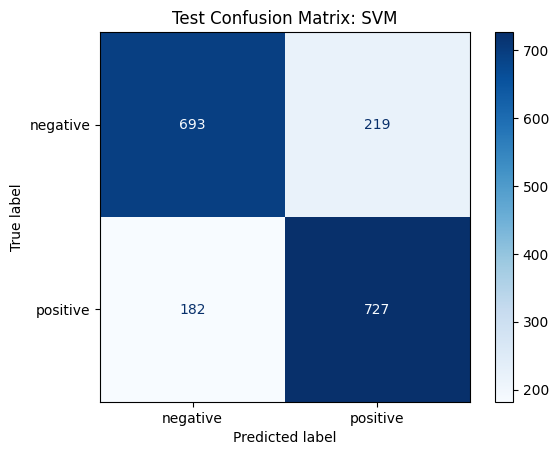


Training model: KNN
10-fold CV weighted F1 scores: [0.53464024 0.52241592 0.51554745 0.51584063 0.47801782 0.44944806
 0.50640337 0.49150561 0.4998198  0.49739777]
Mean CV weighted F1: 0.5011

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.50      0.65      0.57       662
    positive       0.56      0.40      0.47       722

    accuracy                           0.52      1384
   macro avg       0.53      0.53      0.52      1384
weighted avg       0.53      0.52      0.51      1384


Final Test Classification Report:
              precision    recall  f1-score   support

    negative       0.53      0.61      0.57       912
    positive       0.54      0.46      0.49       909

    accuracy                           0.53      1821
   macro avg       0.54      0.53      0.53      1821
weighted avg       0.54      0.53      0.53      1821



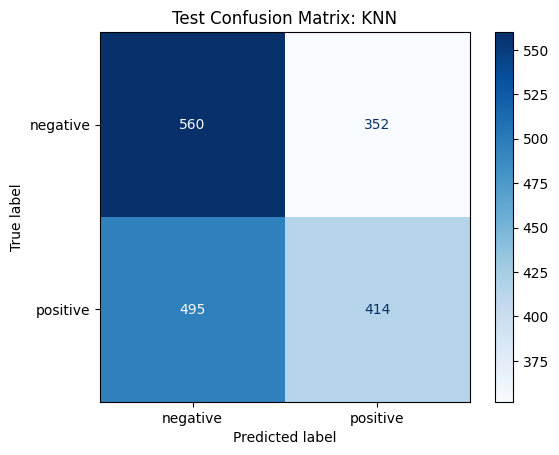


Training model: Decision Tree
10-fold CV weighted F1 scores: [0.5775853  0.53032217 0.54582683 0.54776248 0.52485468 0.52485468
 0.53567101 0.56320645 0.54358047 0.53206671]
Mean CV weighted F1: 0.5426

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.53      0.88      0.66       662
    positive       0.73      0.29      0.41       722

    accuracy                           0.57      1384
   macro avg       0.63      0.58      0.54      1384
weighted avg       0.63      0.57      0.53      1384


Final Test Classification Report:
              precision    recall  f1-score   support

    negative       0.55      0.88      0.68       912
    positive       0.71      0.29      0.41       909

    accuracy                           0.59      1821
   macro avg       0.63      0.59      0.55      1821
weighted avg       0.63      0.59      0.55      1821



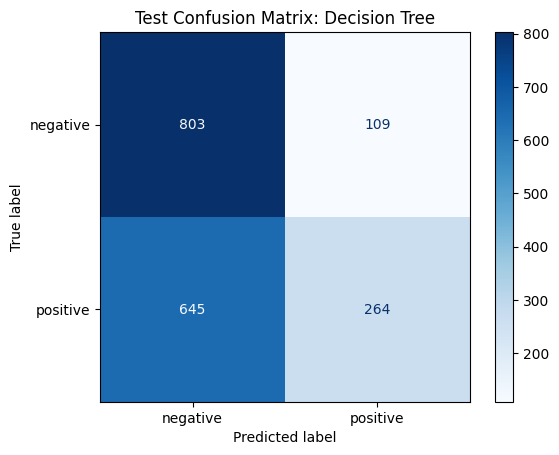


Training model: Random Forest
10-fold CV weighted F1 scores: [0.69841353 0.72908306 0.67110218 0.71078463 0.70124771 0.66951902
 0.68267369 0.68132369 0.69434425 0.69935953]
Mean CV weighted F1: 0.6938

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.65      0.71      0.68       662
    positive       0.71      0.65      0.68       722

    accuracy                           0.68      1384
   macro avg       0.68      0.68      0.68      1384
weighted avg       0.68      0.68      0.68      1384


Final Test Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.79      0.74       912
    positive       0.76      0.65      0.70       909

    accuracy                           0.72      1821
   macro avg       0.73      0.72      0.72      1821
weighted avg       0.73      0.72      0.72      1821



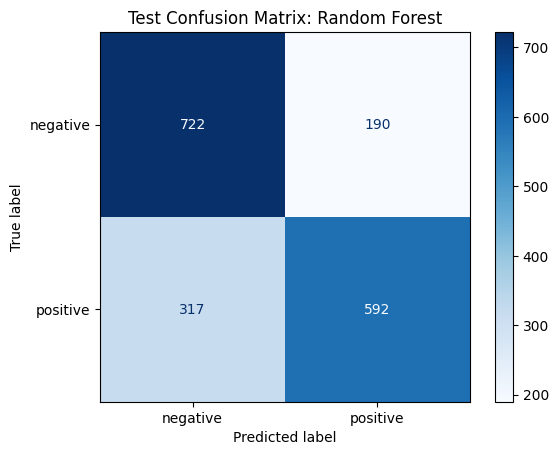

,Model,Mean 10-Fold CV F1,Validation Accuracy,Validation Recall,Validation Precision,Validation F1,Test Accuracy,Test Recall,Test Precision,Test F1
0,SVM,0.741269,0.744220,0.744220,0.744220,0.744220,0.779791,0.779791,0.780269,0.779708
3,Random Forest,0.693785,0.677023,0.677023,0.679381,0.677052,0.721582,0.721582,0.725915,0.720188
2,Decision Tree,0.542573,0.571532,0.571532,0.633886,0.531297,0.585942,0.585942,0.631040,0.546404
1,KNN,0.501104,0.520954,0.520954,0.529376,0.513615,0.534871,0.534871,0.535630,0.531924


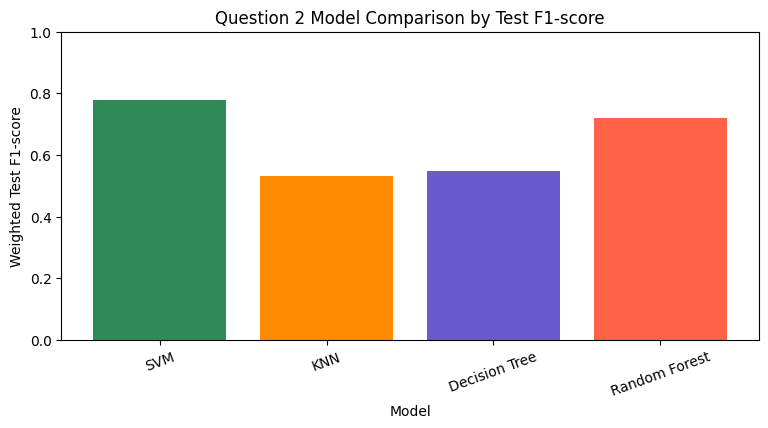


Summary:
The best model on the test dataset was SVM with a weighted test F1-score of 0.7797. All models were trained using TF-IDF features, and 10-fold cross-validation was performed on the training split. The final models were evaluated using accuracy, recall, precision, and F1-score.


In [18]:
# Write your code here

# Includes EDA, 80/20 train-validation split, 10-fold cross-validation,
# 4 ML models, and final test evaluation.

import glob
import re
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# -----------------------------
# 1. Locate dataset files
# -----------------------------

zip_files = glob.glob("/content/*.zip")
txt_files = glob.glob("/content/*.txt")

def load_label_text_lines(lines):
    rows = []

    for line in lines:
        line = line.strip()

        if line:
            label, text = line.split(" ", 1)
            rows.append({
                "label": int(label),
                "text": text
            })

    return pd.DataFrame(rows)


if len(zip_files) > 0:
    zip_path = zip_files[0]
    print("Using zip file:", zip_path)

    with zipfile.ZipFile(zip_path) as z:
        members = z.namelist()
        print("Files inside zip:")
        print(members)

        train_member = [m for m in members if "train" in m.lower() and m.endswith(".txt")][0]
        test_member = [m for m in members if "test" in m.lower() and m.endswith(".txt")][0]

        print("\nTraining file:", train_member)
        print("Testing file:", test_member)

        with z.open(train_member) as f:
            train_lines = [line.decode("utf-8") for line in f]

        with z.open(test_member) as f:
            test_lines = [line.decode("utf-8") for line in f]

    train_df = load_label_text_lines(train_lines)
    test_df = load_label_text_lines(test_lines)

elif len(txt_files) >= 2:
    train_file = [f for f in txt_files if "train" in f.lower()][0]
    test_file = [f for f in txt_files if "test" in f.lower()][0]

    print("Training file:", train_file)
    print("Testing file:", test_file)

    with open(train_file, "r", encoding="utf-8") as f:
        train_lines = f.readlines()

    with open(test_file, "r", encoding="utf-8") as f:
        test_lines = f.readlines()

    train_df = load_label_text_lines(train_lines)
    test_df = load_label_text_lines(test_lines)

else:
    raise FileNotFoundError(
        "No dataset found. Upload the Canvas dataset zip file or the train/test .txt files to /content."
    )


label_map = {
    0: "negative",
    1: "positive"
}

train_df["sentiment"] = train_df["label"].map(label_map)
test_df["sentiment"] = test_df["label"].map(label_map)

print("\nTraining dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

display(train_df.head())
display(test_df.head())


# -----------------------------
# 2. EDA on training and test data
# -----------------------------

print("\nTraining class distribution:")
print(train_df["sentiment"].value_counts())

print("\nTesting class distribution:")
print(test_df["sentiment"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train_df["sentiment"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color=["tomato", "seagreen"]
)
axes[0].set_title("Training Class Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

test_df["sentiment"].value_counts().plot(
    kind="bar",
    ax=axes[1],
    color=["tomato", "seagreen"]
)
axes[1].set_title("Testing Class Distribution")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


train_df["sentence_length"] = train_df["text"].apply(lambda x: len(x.split()))
test_df["sentence_length"] = test_df["text"].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df["sentence_length"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Training Sentence Length")
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Count")

axes[1].hist(test_df["sentence_length"], bins=30, color="darkorange", edgecolor="black")
axes[1].set_title("Testing Sentence Length")
axes[1].set_xlabel("Number of Words")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("\nTraining sentence length summary:")
display(train_df["sentence_length"].describe())

print("\nTesting sentence length summary:")
display(test_df["sentence_length"].describe())


# -----------------------------
# 3. Text cleaning and preprocessing
# -----------------------------

stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = text.lower()
    tokens = re.findall(r"[a-z']+", text)

    tokens = [
        token for token in tokens
        if token not in stop_words and len(token) > 2
    ]

    return " ".join(tokens)

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

display(train_df[["text", "clean_text", "sentiment"]].head())


# -----------------------------
# 4. N-gram EDA
# -----------------------------

def plot_top_terms(text_series, ngram_range=(1, 1), top_n=10, title="Top Terms"):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        max_features=top_n
    )

    counts = vectorizer.fit_transform(text_series)
    terms = vectorizer.get_feature_names_out()
    frequencies = counts.sum(axis=0).A1

    freq_df = pd.DataFrame({
        "term": terms,
        "frequency": frequencies
    }).sort_values("frequency", ascending=True)

    plt.figure(figsize=(7, 4))
    plt.barh(freq_df["term"], freq_df["frequency"], color="darkcyan")
    plt.title(title)
    plt.xlabel("Frequency")
    plt.show()

plot_top_terms(train_df["clean_text"], (1, 1), 10, "Top Training Unigrams")
plot_top_terms(train_df["clean_text"], (2, 2), 10, "Top Training Bigrams")


# -----------------------------
# 5. Split training data into train and validation sets
# 80% training, 20% validation
# -----------------------------

X = train_df["clean_text"]
y = train_df["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_test = test_df["clean_text"]
y_test = test_df["label"]

print("Training split size:", X_train.shape[0])
print("Validation split size:", X_val.shape[0])
print("Test size:", X_test.shape[0])


# -----------------------------
# 6. Build 4 classification models
# Required: 10-fold cross-validation
# -----------------------------

models = {
    "SVM": LinearSVC(
        class_weight="balanced",
        max_iter=5000
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=40
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        max_depth=40,
        n_jobs=1
    )
}

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

results = []
trained_models = {}

for model_name, classifier in models.items():
    print(f"\nTraining model: {model_name}")

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=3000,
            ngram_range=(1, 1)
        )),
        ("clf", classifier)
    ])

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_weighted",
        n_jobs=1
    )

    print(f"10-fold CV weighted F1 scores: {cv_scores}")
    print(f"Mean CV weighted F1: {cv_scores.mean():.4f}")

    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

    val_pred = pipeline.predict(X_val)

    val_accuracy = accuracy_score(y_val, val_pred)
    val_recall = recall_score(y_val, val_pred, average="weighted")
    val_precision = precision_score(y_val, val_pred, average="weighted")
    val_f1 = f1_score(y_val, val_pred, average="weighted")

    print("\nValidation Classification Report:")
    print(classification_report(y_val, val_pred, target_names=["negative", "positive"]))

    # Refit on the full original training dataset before final test evaluation
    final_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=3000,
            ngram_range=(1, 1)
        )),
        ("clf", classifier)
    ])

    final_pipeline.fit(X, y)
    test_pred = final_pipeline.predict(X_test)

    test_accuracy = accuracy_score(y_test, test_pred)
    test_recall = recall_score(y_test, test_pred, average="weighted")
    test_precision = precision_score(y_test, test_pred, average="weighted")
    test_f1 = f1_score(y_test, test_pred, average="weighted")

    results.append({
        "Model": model_name,
        "Mean 10-Fold CV F1": cv_scores.mean(),
        "Validation Accuracy": val_accuracy,
        "Validation Recall": val_recall,
        "Validation Precision": val_precision,
        "Validation F1": val_f1,
        "Test Accuracy": test_accuracy,
        "Test Recall": test_recall,
        "Test Precision": test_precision,
        "Test F1": test_f1
    })

    print("\nFinal Test Classification Report:")
    print(classification_report(y_test, test_pred, target_names=["negative", "positive"]))

    cm = confusion_matrix(y_test, test_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["negative", "positive"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"Test Confusion Matrix: {model_name}")
    plt.show()


# -----------------------------
# 7. Compare all models
# -----------------------------

results_df = pd.DataFrame(results)
display(results_df.sort_values("Test F1", ascending=False))

plt.figure(figsize=(9, 4))
plt.bar(
    results_df["Model"],
    results_df["Test F1"],
    color=["seagreen", "darkorange", "slateblue", "tomato"]
)
plt.title("Question 2 Model Comparison by Test F1-score")
plt.xlabel("Model")
plt.ylabel("Weighted Test F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

best_model = results_df.sort_values("Test F1", ascending=False).iloc[0]

print("\nSummary:")
print(
    f"The best model on the test dataset was {best_model['Model']} with a weighted test F1-score of "
    f"{best_model['Test F1']:.4f}. All models were trained using TF-IDF features, and 10-fold "
    "cross-validation was performed on the training split. The final models were evaluated using "
    "accuracy, recall, precision, and F1-score."
)


## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


Using ZIP dataset: /content/exercise05_datacollection-1.zip

Dataset choice:
I used an alternative real-world movie review text dataset from the uploaded zip file. This dataset is suitable for clustering because it contains many short review texts that can be grouped based on word usage, sentiment-related vocabulary, and topic similarity.

Dataset shape used for clustering: (1000, 2)


,text,source_label
0,a surprisingly charming and even witty match f...,1
1,boring and meandering .,0
2,"terry is a sort of geriatric dirty harry , whi...",1
3,pumpkin sits in a patch somewhere between mirt...,0
4,it is most remarkable not because of its epic ...,1


,text,clean_text,word_count
0,a surprisingly charming and even witty match f...,surprisingly charming witty match best hollywo...,16
1,boring and meandering .,boring meandering,4
2,"terry is a sort of geriatric dirty harry , whi...",terry sort geriatric dirty harry eastwood loya...,36
3,pumpkin sits in a patch somewhere between mirt...,pumpkin sits patch mirthless todd solondzian s...,16
4,it is most remarkable not because of its epic ...,remarkable epic scope startling intimacy achie...,23



Word count summary:


,word_count
count,997.000000
mean,19.584754
std,9.241630
min,2.000000
25%,12.000000
50%,19.000000
75%,26.000000
max,52.000000


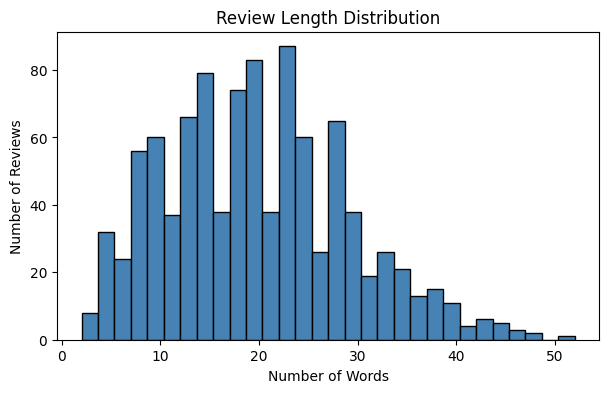

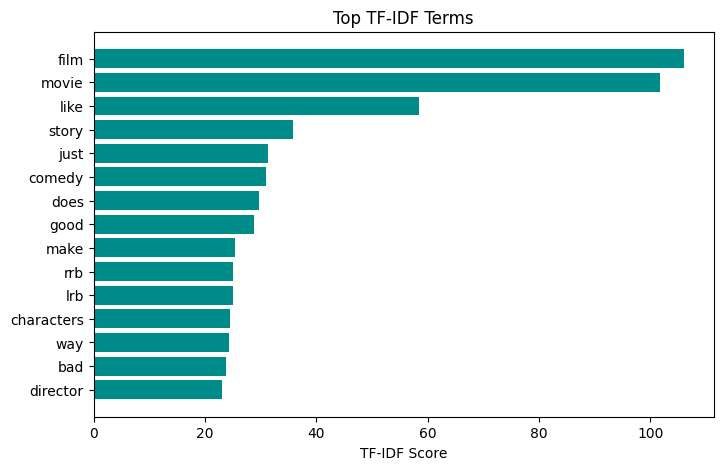

TF-IDF matrix shape: (997, 1406)
Reduced feature shape: (997, 50)

K-means cluster counts:
kmeans_cluster
0     35
1    701
2     33
3    104
4    124
Name: count, dtype: int64
K-means silhouette score: 0.08828308538053077


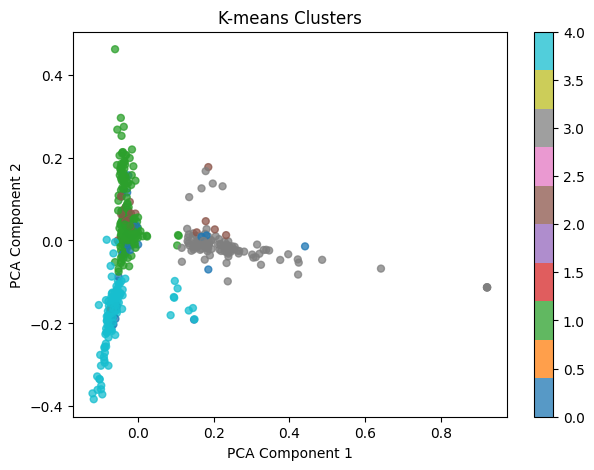


Cluster 0 examples:
- sometimes there are very , very good reasons for certain movies to be sealed in a jar and left on a remote shelf indefinitely .
- nothing short of wonderful with its ten-year-old female protagonist and its steadfast refusal to set up a dualistic battle between good and evil .
- scores a few points for doing what it does with a dedicated and good-hearted professionalism .

Cluster 1 examples:
- a surprisingly charming and even witty match for the best of hollywood 's comic-book adaptations .
- boring and meandering .
- terry is a sort of geriatric dirty harry , which will please eastwood 's loyal fans -- and suits the story , wherein our hero must ride roughshod over incompetent cops to get his man .

Cluster 2 examples:
- a cruelly funny twist on teen comedy packed with inventive cinematic tricks and an ironically killer soundtrack
- nothing more than four or five mild chuckles surrounded by 86 minutes of overly-familiar and poorly-constructed comedy .
- the movi

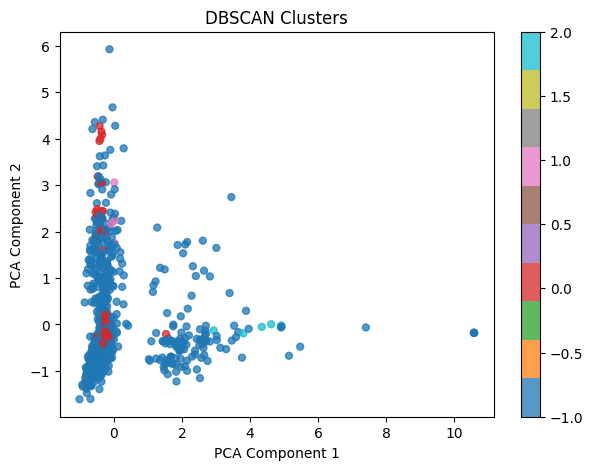


Cluster -1 examples:
- a surprisingly charming and even witty match for the best of hollywood 's comic-book adaptations .
- boring and meandering .
- terry is a sort of geriatric dirty harry , which will please eastwood 's loyal fans -- and suits the story , wherein our hero must ride roughshod over incompetent cops to get his man .

Cluster 0 examples:
- pumpkin sits in a patch somewhere between mirthless todd solondzian satire and callow student film .
- brilliantly written and well-acted , yellow asphalt is an uncompromising film .
- unlike his directorial efforts , la femme nikita and the professional , the transporter lacks besson 's perspective as a storyteller .

Cluster 1 examples:
- -lrb- a -rrb- crushing disappointment .
- -lrb- a -rrb- superbly controlled , passionate adaptation of graham greene 's 1955 novel .
- -lrb- sports -rrb- admirable energy , full-bodied characterizations and narrative urgency .

Cluster 2 examples:
- a thoughtful movie , a movie that is concerned w

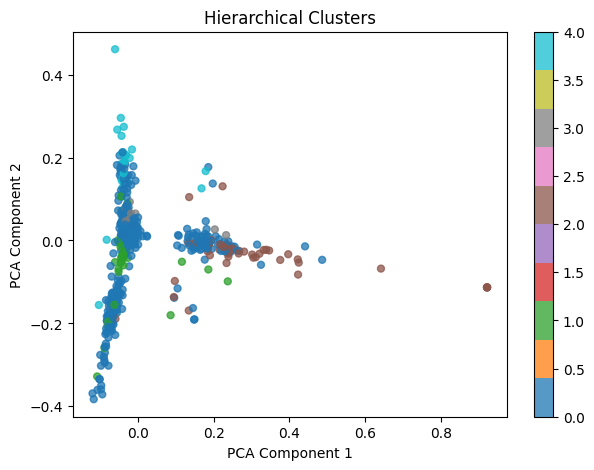


Cluster 0 examples:
- a surprisingly charming and even witty match for the best of hollywood 's comic-book adaptations .
- boring and meandering .
- terry is a sort of geriatric dirty harry , which will please eastwood 's loyal fans -- and suits the story , wherein our hero must ride roughshod over incompetent cops to get his man .

Cluster 1 examples:
- -lrb- a -rrb- strong piece of work .
- birot 's directorial debut -lrb- she co-wrote the script with christophe honoré -rrb- is n't so much bad as it is bland .
- ... -lrb- the film -rrb- works , due mostly to the tongue-in-cheek attitude of the screenplay .

Cluster 2 examples:
- anyone else who may , for whatever reason , be thinking about going to see this movie is hereby given fair warning .
- what a bewilderingly brilliant and entertaining movie this is .
- it 's a terrific american sports movie and dennis quaid is its athletic heart .

Cluster 3 examples:
- i could n't help but feel the wasted potential of this slapstick comedy 

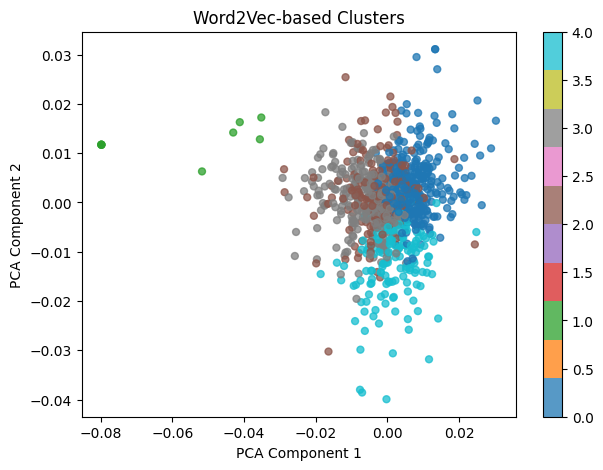


Cluster 0 examples:
- terry is a sort of geriatric dirty harry , which will please eastwood 's loyal fans -- and suits the story , wherein our hero must ride roughshod over incompetent cops to get his man .
- pumpkin sits in a patch somewhere between mirthless todd solondzian satire and callow student film .
- it is most remarkable not because of its epic scope , but because of the startling intimacy it achieves despite that breadth .

Cluster 1 examples:
- what a bewilderingly brilliant and entertaining movie this is .
- the movie bounces all over the map .
- rarely , a movie is more than a movie .

Cluster 2 examples:
- like mike does n't win any points for originality .
- he does n't , however , deliver nearly enough of the show 's trademark style and flash .
- birot 's directorial debut -lrb- she co-wrote the script with christophe honoré -rrb- is n't so much bad as it is bland .

Cluster 3 examples:
- boring and meandering .
- -lrb- a -rrb- strong piece of work .
- ... stumbles o

,Number of clusters,Silhouette score
K-means,5.0,0.088283
DBSCAN,4.0,-0.165296
Hierarchical,5.0,0.081617
Word2Vec + K-means,5.0,0.024333


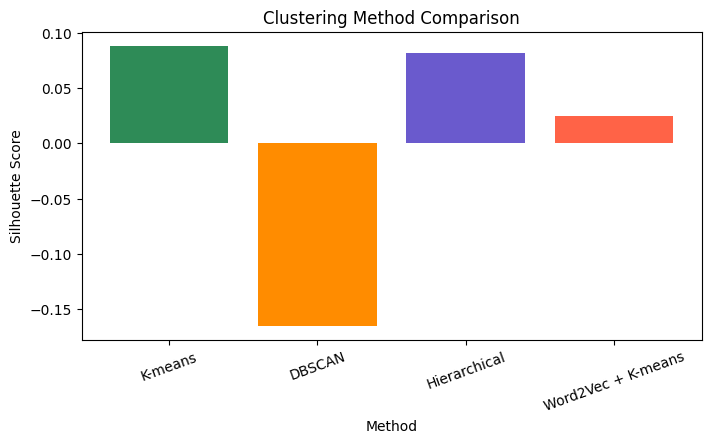


Final Comparison Paragraph:
In this text clustering task, K-means, DBSCAN, Hierarchical clustering, and Word2Vec-based clustering produced different types of groupings. K-means created a fixed number of clusters and was easy to interpret, especially after TF-IDF and dimensionality reduction. DBSCAN was useful for identifying dense groups and outliers, but it was more sensitive to parameter choices such as eps and min_samples. Hierarchical clustering also produced a fixed number of clusters and gave results similar to K-means, but it can become slower for larger datasets. Word2Vec-based clustering used learned word embeddings instead of only TF-IDF term weights, so it captured more semantic similarity between reviews. Based on the silhouette scores in this run, K-means gave the strongest clustering structure among the four methods.


In [19]:
# Write your code here

import glob
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


# -----------------------------
# 1. Load dataset
# -----------------------------

csv_files = glob.glob("/content/*.csv")
zip_files = glob.glob("/content/*.zip")

def load_stsa_zip(zip_path):
    rows = []

    with zipfile.ZipFile(zip_path) as z:
        members = z.namelist()
        text_files = [m for m in members if m.endswith(".txt")]

        for member in text_files:
            with z.open(member) as file:
                for raw_line in file:
                    line = raw_line.decode("utf-8").strip()

                    if line:
                        parts = line.split(" ", 1)
                        if len(parts) == 2:
                            label, text = parts
                            rows.append({
                                "text": text,
                                "source_label": int(label)
                            })

    return pd.DataFrame(rows)

if len(csv_files) > 0:
    csv_path = csv_files[0]
    print("Using CSV dataset:", csv_path)

    df = pd.read_csv(csv_path)

    print("Columns in uploaded CSV:")
    print(df.columns)

    # Common column names in the Amazon unlocked mobile phone review dataset
    possible_text_columns = ["Reviews", "Review", "review", "Text", "text", "reviewText"]

    text_column = None
    for col in possible_text_columns:
        if col in df.columns:
            text_column = col
            break

    if text_column is None:
        raise ValueError("Could not find a review/text column. Check the CSV column names above.")

    df = df[[text_column]].rename(columns={text_column: "text"})
    dataset_description = (
        "I used the Amazon mobile phone reviews dataset. The dataset is suitable for text clustering "
        "because it contains many customer review texts that can be grouped by vocabulary and topic similarity."
    )

elif len(zip_files) > 0:
    zip_path = zip_files[0]
    print("Using ZIP dataset:", zip_path)

    df = load_stsa_zip(zip_path)
    dataset_description = (
        "I used an alternative real-world movie review text dataset from the uploaded zip file. "
        "This dataset is suitable for clustering because it contains many short review texts that can be grouped "
        "based on word usage, sentiment-related vocabulary, and topic similarity."
    )

else:
    raise FileNotFoundError(
        "No dataset found. Upload either the Amazon reviews CSV file or exercise05_datacollection-1.zip."
    )

df = df.dropna(subset=["text"])
df["text"] = df["text"].astype(str)

# Use a smaller sample so clustering runs quickly in Colab
sample_size = min(1000, len(df))
df = df.sample(sample_size, random_state=42).reset_index(drop=True)

print("\nDataset choice:")
print(dataset_description)

print("\nDataset shape used for clustering:", df.shape)
display(df.head())


# -----------------------------
# 2. Text cleaning
# -----------------------------

stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = text.lower()
    tokens = re.findall(r"[a-z']+", text)

    tokens = [
        token for token in tokens
        if token not in stop_words and len(token) > 2
    ]

    return " ".join(tokens)

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

df["word_count"] = df["text"].apply(lambda x: len(x.split()))

display(df[["text", "clean_text", "word_count"]].head())


# -----------------------------
# 3. EDA
# -----------------------------

print("\nWord count summary:")
display(df["word_count"].describe())

plt.figure(figsize=(7, 4))
plt.hist(df["word_count"], bins=30, color="steelblue", edgecolor="black")
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()


def plot_top_terms(text_series, top_n=15):
    vectorizer = TfidfVectorizer(max_features=top_n)
    matrix = vectorizer.fit_transform(text_series)

    terms = vectorizer.get_feature_names_out()
    scores = matrix.sum(axis=0).A1

    term_df = pd.DataFrame({
        "term": terms,
        "score": scores
    }).sort_values("score", ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(term_df["term"], term_df["score"], color="darkcyan")
    plt.title("Top TF-IDF Terms")
    plt.xlabel("TF-IDF Score")
    plt.show()

plot_top_terms(df["clean_text"], top_n=15)


# -----------------------------
# 4. TF-IDF vectorization
# -----------------------------

tfidf = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.90
)

tfidf_matrix = tfidf.fit_transform(df["clean_text"])

# Reduce dimensionality for clustering
svd = TruncatedSVD(n_components=50, random_state=42)
reduced_features = svd.fit_transform(tfidf_matrix)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(reduced_features)

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Reduced feature shape:", reduced_features.shape)


# -----------------------------
# 5. Helper functions
# -----------------------------

cluster_results = {}

def safe_silhouette(features, labels):
    unique_labels = set(labels)

    # Silhouette score requires at least 2 clusters and fewer clusters than samples
    if len(unique_labels) < 2 or len(unique_labels) >= len(labels):
        return np.nan

    # Ignore DBSCAN noise-only issue
    if unique_labels == {-1}:
        return np.nan

    return silhouette_score(features, labels)

def plot_clusters_2d(features, labels, title):
    pca = PCA(n_components=2, random_state=42)
    points = pca.fit_transform(features)

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(
        points[:, 0],
        points[:, 1],
        c=labels,
        cmap="tab10",
        s=25,
        alpha=0.75
    )
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar(scatter)
    plt.show()

def show_cluster_examples(dataframe, label_column, text_column="text", examples_per_cluster=3):
    for cluster_id in sorted(dataframe[label_column].unique()):
        print(f"\nCluster {cluster_id} examples:")

        examples = dataframe[dataframe[label_column] == cluster_id][text_column].head(examples_per_cluster)

        for example in examples:
            print("-", example[:250])


# -----------------------------
# 6. Method 1: K-means clustering
# -----------------------------

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["kmeans_cluster"] = kmeans.fit_predict(reduced_features)

kmeans_silhouette = safe_silhouette(reduced_features, df["kmeans_cluster"])

cluster_results["K-means"] = {
    "Number of clusters": df["kmeans_cluster"].nunique(),
    "Silhouette score": kmeans_silhouette
}

print("\nK-means cluster counts:")
print(df["kmeans_cluster"].value_counts().sort_index())
print("K-means silhouette score:", kmeans_silhouette)

plot_clusters_2d(reduced_features, df["kmeans_cluster"], "K-means Clusters")
show_cluster_examples(df, "kmeans_cluster")


# -----------------------------
# 7. Method 2: DBSCAN clustering
# -----------------------------

dbscan = DBSCAN(
    eps=3.0,
    min_samples=5
)

df["dbscan_cluster"] = dbscan.fit_predict(scaled_features)

dbscan_silhouette = safe_silhouette(scaled_features, df["dbscan_cluster"])

cluster_results["DBSCAN"] = {
    "Number of clusters": df["dbscan_cluster"].nunique(),
    "Silhouette score": dbscan_silhouette
}

print("\nDBSCAN cluster counts:")
print(df["dbscan_cluster"].value_counts().sort_index())
print("DBSCAN silhouette score:", dbscan_silhouette)
print("Note: DBSCAN label -1 means noise/outliers.")

plot_clusters_2d(scaled_features, df["dbscan_cluster"], "DBSCAN Clusters")
show_cluster_examples(df, "dbscan_cluster")


# -----------------------------
# 8. Method 3: Hierarchical clustering
# -----------------------------

hierarchical = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

df["hierarchical_cluster"] = hierarchical.fit_predict(reduced_features)

hierarchical_silhouette = safe_silhouette(reduced_features, df["hierarchical_cluster"])

cluster_results["Hierarchical"] = {
    "Number of clusters": df["hierarchical_cluster"].nunique(),
    "Silhouette score": hierarchical_silhouette
}

print("\nHierarchical cluster counts:")
print(df["hierarchical_cluster"].value_counts().sort_index())
print("Hierarchical silhouette score:", hierarchical_silhouette)

plot_clusters_2d(reduced_features, df["hierarchical_cluster"], "Hierarchical Clusters")
show_cluster_examples(df, "hierarchical_cluster")


# -----------------------------
# 9. Method 4: Word2Vec-based clustering
# This trains a small Word2Vec model on the dataset.
# -----------------------------

try:
    from gensim.models import Word2Vec

except ImportError:
    import sys
    import subprocess

    print("Installing gensim for Word2Vec...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gensim"])
    from gensim.models import Word2Vec


tokenized_reviews = df["clean_text"].apply(lambda x: x.split()).tolist()

w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=50,
    window=5,
    min_count=2,
    workers=1,
    seed=42
)

def document_vector(tokens, model):
    vectors = [
        model.wv[token]
        for token in tokens
        if token in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

w2v_features = np.array([
    document_vector(tokens, w2v_model)
    for tokens in tokenized_reviews
])

w2v_kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["word2vec_cluster"] = w2v_kmeans.fit_predict(w2v_features)

word2vec_silhouette = safe_silhouette(w2v_features, df["word2vec_cluster"])

cluster_results["Word2Vec + K-means"] = {
    "Number of clusters": df["word2vec_cluster"].nunique(),
    "Silhouette score": word2vec_silhouette
}

print("\nWord2Vec-based cluster counts:")
print(df["word2vec_cluster"].value_counts().sort_index())
print("Word2Vec-based silhouette score:", word2vec_silhouette)

plot_clusters_2d(w2v_features, df["word2vec_cluster"], "Word2Vec-based Clusters")
show_cluster_examples(df, "word2vec_cluster")


# -----------------------------
# 10. Compare clustering methods
# -----------------------------

cluster_summary = pd.DataFrame(cluster_results).T
display(cluster_summary)

plt.figure(figsize=(8, 4))
plt.bar(
    cluster_summary.index,
    cluster_summary["Silhouette score"],
    color=["seagreen", "darkorange", "slateblue", "tomato"]
)
plt.title("Clustering Method Comparison")
plt.xlabel("Method")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=20)
plt.show()


# -----------------------------
# 11. Final written comparison
# -----------------------------

best_method = cluster_summary["Silhouette score"].astype(float).idxmax()

print("\nFinal Comparison Paragraph:")
print(
    f"In this text clustering task, K-means, DBSCAN, Hierarchical clustering, and Word2Vec-based clustering "
    f"produced different types of groupings. K-means created a fixed number of clusters and was easy to interpret, "
    f"especially after TF-IDF and dimensionality reduction. DBSCAN was useful for identifying dense groups and "
    f"outliers, but it was more sensitive to parameter choices such as eps and min_samples. Hierarchical clustering "
    f"also produced a fixed number of clusters and gave results similar to K-means, but it can become slower for "
    f"larger datasets. Word2Vec-based clustering used learned word embeddings instead of only TF-IDF term weights, "
    f"so it captured more semantic similarity between reviews. Based on the silhouette scores in this run, "
    f"{best_method} gave the strongest clustering structure among the four methods."
)


In this text clustering task, K-means, DBSCAN, Hierarchical clustering, and Word2Vec-based clustering produced different types of groupings. K-means created a fixed number of clusters and was easy to interpret, especially after TF-IDF vectorization and dimensionality reduction. DBSCAN was useful for identifying dense groups and outliers, but it was more sensitive to parameter choices such as eps and min_samples. Hierarchical clustering also produced a fixed number of clusters and gave results similar to K-means, although it can become slower for larger datasets. Word2Vec-based clustering used learned word embeddings instead of only TF-IDF term weights, so it captured more semantic similarity between reviews. Based on the silhouette scores in this run, K-means gave the strongest clustering structure among the four methods.


**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

**Write your response here:**

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

